#### Loading CSV File

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

csv_path = Path(
    "/Users/rgaffney/Downloads/INST414/"
    "imdb_movies_2000to2022.actorXgenre.csv"
)

print("File exists:", csv_path.exists())

actor_genre_df = pd.read_csv(
    csv_path,
    index_col="actor_id"
)

print("Data matrix shape:", actor_genre_df.shape)
display(actor_genre_df.head())

File exists: True
Data matrix shape: (33609, 25)


,Comedy,Fantasy,Romance,Drama,Mystery,Thriller,Action,Biography,Crime,War,...,Horror,Documentary,Sport,News,Family,Music,Unnamed: 22,Western,Short,Reality-TV
actor_id,,,,,,,,,,,,,,,,,,,,,
nm0000212,7.0,1.0,6.0,6.0,1.0,2.0,1.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0413168,7.0,3.0,5.0,12.0,5.0,2.0,14.0,4.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0000630,8.0,2.0,6.0,14.0,2.0,3.0,4.0,5.0,1.0,1.0,...,3.0,7.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0005227,10.0,1.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
nm0864851,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Interia Analysis

In [9]:
k_values = range(2, 31)
inertia_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(actor_genre_df)
    inertia_values.append(model.inertia_)

    print(f"k={k}: inertia={model.inertia_:.2f}")

k=2: inertia=391327.87
k=3: inertia=333296.09
k=4: inertia=324048.39
k=5: inertia=299330.01
k=6: inertia=289541.58
k=7: inertia=273773.71
k=8: inertia=250986.96
k=9: inertia=243452.98
k=10: inertia=233653.10
k=11: inertia=227073.82
k=12: inertia=221513.92
k=13: inertia=214921.42
k=14: inertia=207895.90
k=15: inertia=204362.54
k=16: inertia=198195.05
k=17: inertia=194679.61
k=18: inertia=191977.26
k=19: inertia=189876.78
k=20: inertia=187470.48
k=21: inertia=180667.54
k=22: inertia=177983.44
k=23: inertia=175262.59
k=24: inertia=171832.70
k=25: inertia=170229.29
k=26: inertia=167241.71
k=27: inertia=166208.72
k=28: inertia=164057.19
k=29: inertia=163313.19
k=30: inertia=162038.37


#### DataFrame results

In [10]:
inertia_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values
})

display(inertia_df)

,k,inertia
0,2,391327.868296
1,3,333296.093384
2,4,324048.389058
3,5,299330.012769
4,6,289541.581149
5,7,273773.705883
6,8,250986.964725
7,9,243452.975046
8,10,233653.104359
9,11,227073.817437


#### Elbow Curve Plot

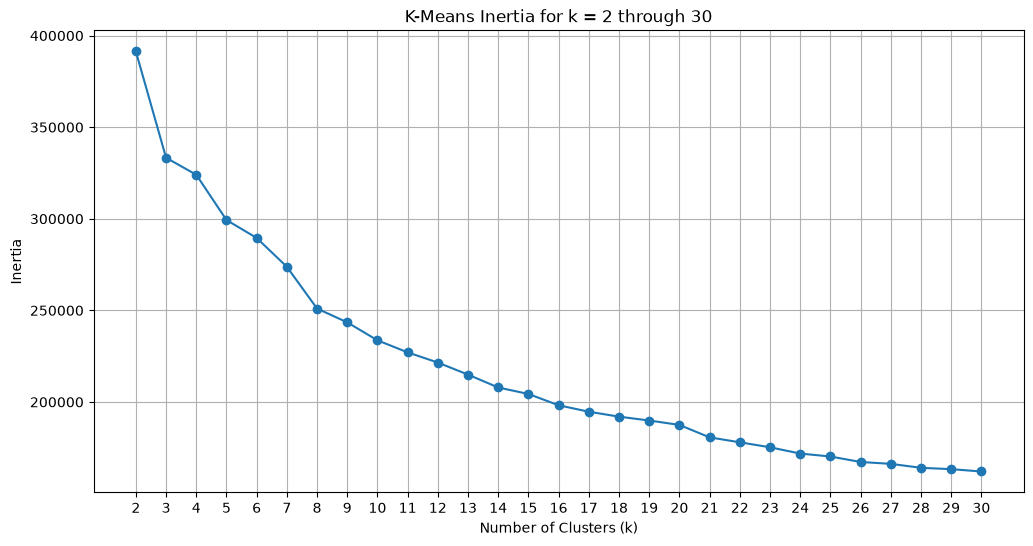

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    inertia_df["k"],
    inertia_df["inertia"],
    marker="o"
)

plt.title("K-Means Inertia for k = 2 through 30")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(2, 31))
plt.grid(True)

plt.show()